Initial Class Distribution:
oestrus     7944
calving     4296
lameness    3216
mastitis    1056
dtype: int64


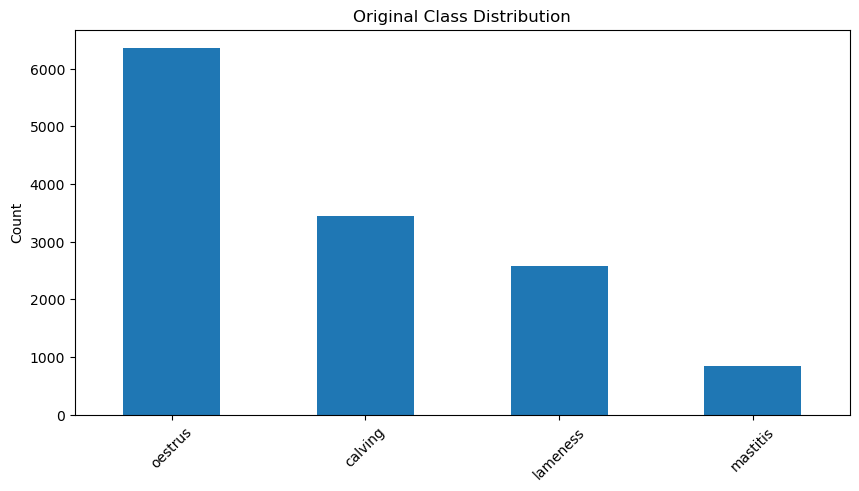


Applying SMOTE to each target separately...

Resampling oestrus...

Resampling calving...

Resampling lameness...

Resampling mastitis...

SMOTE Class Distribution:
oestrus     5742277.0
calving     5755825.0
lameness    5758165.0
mastitis    5759940.0
dtype: float64


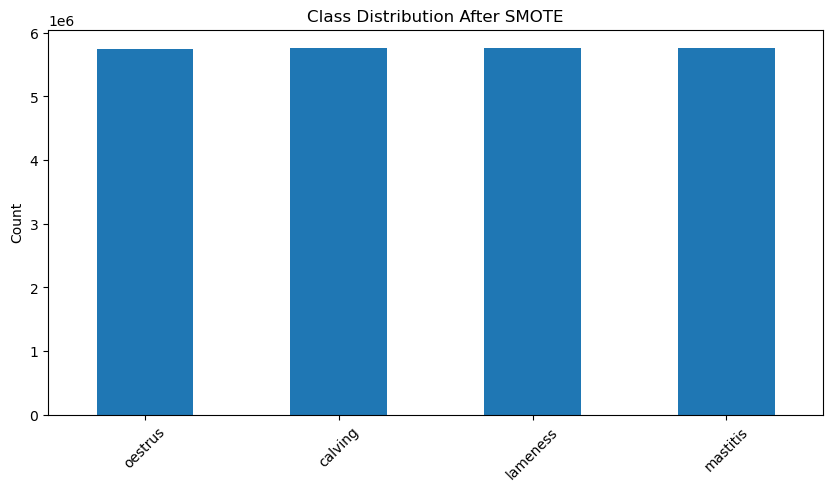


Applying ADASYN to each target separately...

Resampling oestrus...

Resampling calving...

Resampling lameness...

Resampling mastitis...

ADASYN Class Distribution:
oestrus     5741537.0
calving     5763680.0
lameness    5766261.0
mastitis    5767577.0
dtype: float64


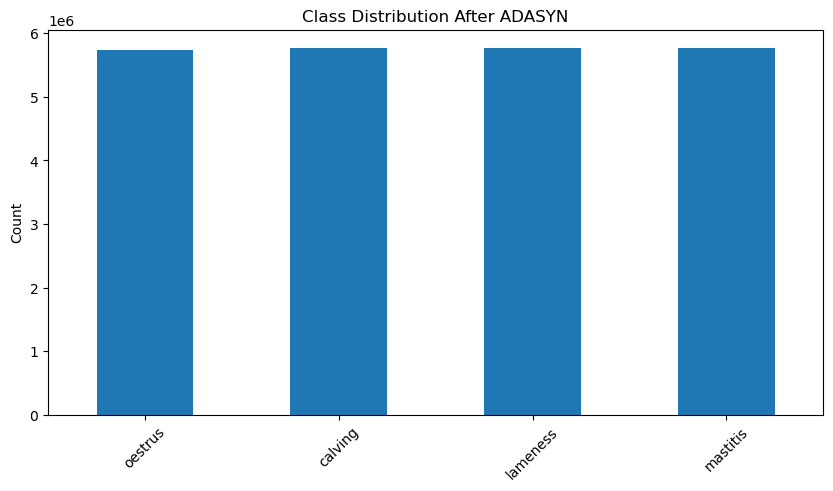


Evaluating on original imbalanced data:

Evaluating Original Imbalanced Data...

Classification Report for oestrus:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    385545
           1       0.02      0.00      0.00      1589

    accuracy                           1.00    387134
   macro avg       0.51      0.50      0.50    387134
weighted avg       0.99      1.00      0.99    387134


Classification Report for calving:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    386275
           1       0.05      0.01      0.01       859

    accuracy                           1.00    387134
   macro avg       0.52      0.50      0.51    387134
weighted avg       1.00      1.00      1.00    387134


Classification Report for lameness:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    386491
           1       0.00      0.00      0.00    

ValueError: Input y contains NaN.

In [3]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE, ADASYN
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# Loading  dataset
df = pd.read_csv("full_data_unhealthy_imputed.csv")

# Define features and multi-output target
features = ['IN_ALLEYS', 'REST', 'EAT', 'ACTIVITY_LEVEL', 'hour']
targets = ['oestrus', 'calving', 'lameness', 'mastitis']

# Extract features and targets
X = df[features]
y = df[targets]

# Check initial class distribution
print("Initial Class Distribution:")
print(y.sum())

# Split data first to avoid leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # Preserve class distribution in splits
)

# Function to plot class distribution
def plot_class_distribution(y, title):
    y.sum().plot(kind='bar', figsize=(10, 5))
    plt.title(title)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

# Plot original distribution
plot_class_distribution(y_train, "Original Class Distribution")

# Modified Approach for Multi-Output Resampling
def resample_multioutput(X, y, sampler):
    """
    Custom resampling for multi-output targets
    Returns resampled X and y with balanced classes for each target
    """
    resampled_X = []
    resampled_y = []
    
    for target_col in y.columns:
        print(f"\nResampling {target_col}...")
        sampler_instance = sampler(random_state=42)
        
        # Resample for current target
        X_res, y_res = sampler_instance.fit_resample(X, y[target_col])
        
        resampled_X.append(X_res)
        resampled_y.append(y_res)
    
    # Combine all resampled data
    X_combined = pd.concat(resampled_X)
    y_combined = pd.concat(resampled_y, axis=1)
    
    # Remove duplicates while preserving class balance
    X_final = X_combined.drop_duplicates()
    y_final = y_combined.loc[X_final.index]
    
    return X_final, y_final

# Option 1: SMOTE for Multi-Output
print("\nApplying SMOTE to each target separately...")
X_res_smote, y_res_smote = resample_multioutput(X_train, y_train, SMOTE)
print("\nSMOTE Class Distribution:")
print(y_res_smote.sum())
plot_class_distribution(y_res_smote, "Class Distribution After SMOTE")

# Option 2: ADASYN
print("\nApplying ADASYN to each target separately...")
X_res_adasyn, y_res_adasyn = resample_multioutput(X_train, y_train, ADASYN)
print("\nADASYN Class Distribution:")
print(y_res_adasyn.sum())
plot_class_distribution(y_res_adasyn, "Class Distribution After ADASYN")

# Function to train and evaluate
def evaluate_model(X_train, y_train, X_test, y_test, method_name):
    print(f"\nEvaluating {method_name}...")
    
    # Train model
    model = MultiOutputClassifier(RandomForestClassifier(random_state=42))
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Evaluate each target
    for i, target in enumerate(targets):
        print(f"\nClassification Report for {target}:")
        print(classification_report(y_test[target], y_pred[:, i]))
    
    return model

# Evaluate original imbalanced data
print("\nEvaluating on original imbalanced data:")
original_model = evaluate_model(X_train, y_train, X_test, y_test, "Original Imbalanced Data")

# Evaluate SMOTE-resampled data
print("\nEvaluating on SMOTE-resampled data:")
smote_model = evaluate_model(X_res_smote, y_res_smote, X_test, y_test, "SMOTE Resampled Data")

# Evaluate ADASYN-resampled data
print("\nEvaluating on ADASYN-resampled data:")
adasyn_model = evaluate_model(X_res_adasyn, y_res_adasyn, X_test, y_test, "ADASYN Resampled Data")

# Feature importance analysis
print("\nFeature Importances:")
for i, target in enumerate(targets):
    print(f"\nFor {target}:")
    importances = smote_model.estimators_[i].feature_importances_
    for feature, importance in zip(features, importances):
        print(f"{feature}: {importance:.4f}")

# Save resampled datasets
X_res_smote.to_csv("smote_resampled_features.csv", index=False)
y_res_smote.to_csv("smote_resampled_targets.csv", index=False)
X_res_adasyn.to_csv("adasyn_resampled_features.csv", index=False)
y_res_adasyn.to_csv("adasyn_resampled_targets.csv", index=False)

print("\nResampled datasets saved to CSV files.")

In [1]:
import pandas as pd
from imblearn.over_sampling import SMOTE, ADASYN
from sklearn.model_selection import train_test_split

# Load data
df = pd.read_csv("full_data_unhealthy_imputed.csv")
features = ['IN_ALLEYS', 'REST', 'EAT', 'ACTIVITY_LEVEL', 'hour']
targets = ['oestrus', 'calving', 'lameness', 'mastitis']

# Prepare data
X = df[features]
y = df[targets]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def balanced_resample(X, y, sampler_name, target_size=1500000):
    """Simple resampling with size control"""
    sampler = SMOTE(random_state=42) if sampler_name == "SMOTE" else ADASYN(random_state=42)
    
    # Resampling each target separately
    resampled = []
    for target in targets:
        print(f"Resampling {target} using {sampler_name}...")
        X_res, y_res = sampler.fit_resample(X, y[target])
        resampled.append(pd.DataFrame(X_res, columns=features).assign(target=target, value=y_res))
    
    # Combine and sample to target size
    combined = pd.concat(resampled)
    final_df = combined.sample(min(len(combined), target_size), random_state=42)
    
    # Prepare X and y
    X_final = final_df[features]
    y_final = pd.get_dummies(final_df['target']).mul(final_df['value'], axis=0)
    
    return X_final, y_final[targets]

# Applying SMOTE
X_smote, y_smote = balanced_resample(X_train, y_train, "SMOTE")
print("\nSMOTE Resampled Data Shape:", X_smote.shape)
print("Class Distribution:\n", y_smote.sum())

# Applying ADASYN
X_adasyn, y_adasyn = balanced_resample(X_train, y_train, "ADASYN")
print("\nADASYN Resampled Data Shape:", X_adasyn.shape)
print("Class Distribution:\n", y_adasyn.sum())

# Save results
pd.concat([X_smote, y_smote], axis=1).to_csv("smote_1.5M.csv", index=False)
pd.concat([X_adasyn, y_adasyn], axis=1).to_csv("adasyn_1.5M.csv", index=False)

Resampling oestrus using SMOTE...
Resampling calving using SMOTE...
Resampling lameness using SMOTE...
Resampling mastitis using SMOTE...

SMOTE Resampled Data Shape: (1500000, 5)
Class Distribution:
 oestrus     187526
calving     187505
lameness    187242
mastitis    187961
dtype: int64
Resampling oestrus using ADASYN...
Resampling calving using ADASYN...
Resampling lameness using ADASYN...
Resampling mastitis using ADASYN...

ADASYN Resampled Data Shape: (1500000, 5)
Class Distribution:
 oestrus     187672
calving     188203
lameness    187003
mastitis    187244
dtype: int64
